## Exoplanet Data Analysis

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
exo_data = pd.read_csv("exoplanet_data.csv", comment = "#")

In [4]:
print(exo_data.shape) # There are 583 rows and 92 columns.

(583, 92)


In [5]:
print(exo_data.columns)

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

5 columns I'm unsure about:
- pl_bmassjer1
- pl_insolerr2
- pl_insollim
- pl_eqt
- ttv_flag

- Planet name: pl_name; Planet name most commonly used in the literature. Self-explanatory.
- Host name: hostname; Stellar name most commonly used in the literature. The name of the star the planet orbits.
- Discovery method: discoverymethod; Method by which the planet was first identified. Self-explanatory.
- Spectral type: st_spectype; Classification of the star based on their spectral characteristics following the Morgan-Keenan system. In laymen's terms, the "letter" that the star is classified as (O, F, B, etc.)
- Equilibrium temperature (K): pl_eqt; The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body. The equilibrium temperature of the plaent, assuming 100% transmission of light.
- Planet mass or Mass*sin(i) [Jupiter Mass]: pl_bmassj; Best planet mass estimate available, in order of preference: Mass, M*sin(i)/sin(i), or M*sin(i), depending on availability, and measured in Jupiter masses. Self-explanatory.

In [6]:
exo_filtered = exo_data[['pl_name','hostname','discoverymethod','st_spectype','pl_eqt','pl_bmassj']]

In [11]:
exo_filtered = exo_filtered.dropna()

In [13]:
exo_filtered.shape
#There are 70 rows and 6 columns.

(70, 6)

In [14]:
exo_filtered.head()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
3,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
5,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
7,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
8,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
10,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000


In [15]:
exo_filtered.tail()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
562,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980
565,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000
569,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300
572,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709
581,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,6.310


In [17]:
exo_filtered.columns

Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')

#### 4.4 Analyze Data

In [18]:
exo_data['discoverymethod'].value_counts()

discoverymethod
Transit                      392
Radial Velocity              118
Microlensing                  61
Imaging                        6
Transit Timing Variations      3
Eclipse Timing Variations      2
Disk Kinematics                1
Name: count, dtype: int64

There are 7 different discovery methods, with transit being the most common and disk kinematics being the least common. 
- **Transit**: planet discovered by observing dip in light transmission from star it orbits when planet passes in front of star.
- **Radial Velocity**: detects exoplanets by measuring the tiny "wobble" of a star caused by an orbiting planet's gravity.
- **Microlensing**: gravity-based technique used to detect exoplanets by observing the temporary brightening of a distant star as a closer star passes in front of it
- **Imaging**: detection by capturing photons directly from the planet rather than from its host star
- **Transit Timing Variations**: method for detecting exoplanets by observing variations in the timing of a transit.
- **Eclipse Timing Variations**: detect exoplanets by observing irregularities in the predictable, periodic eclipses of binary star systems
- **Disk Kinematics**: detection by morphology of protoplanetary disk gas velocities

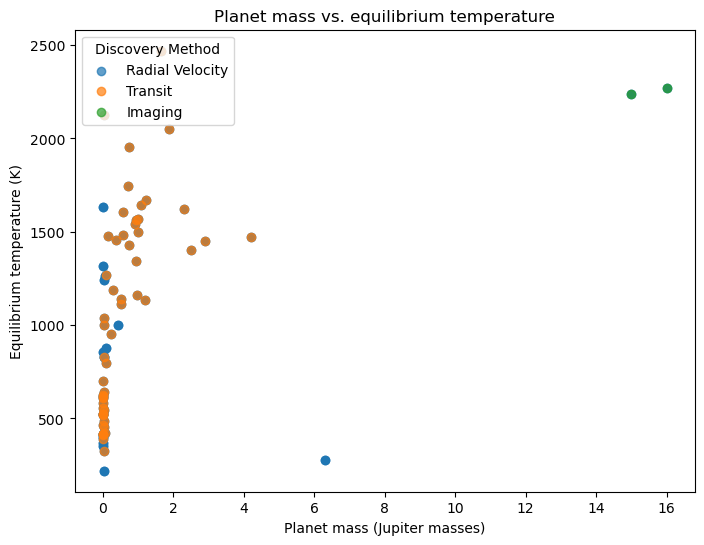

In [36]:
plt.figure(figsize=(8, 6))

discovery_methods = exo_filtered['discoverymethod'].unique()
colors = plt.cm.tab10.colors  # Up to 10 distinct colors

plt.scatter(exo_filtered['pl_bmassj'], exo_filtered['pl_eqt'])
for i, method in enumerate(discovery_methods):
    subset = exo_filtered[exo_filtered['discoverymethod'] == method]
    plt.scatter(
        subset['pl_bmassj'],
        subset['pl_eqt'],
        label=method,
        color=colors[i % len(colors)],
        alpha=0.7
    )
plt.xlabel('Planet mass (Jupiter masses)')
plt.ylabel('Equilibrium temperature (K)')
plt.title('Planet mass vs. equilibrium temperature')
plt.legend(title='Discovery Method', loc='upper left')

plt.show()

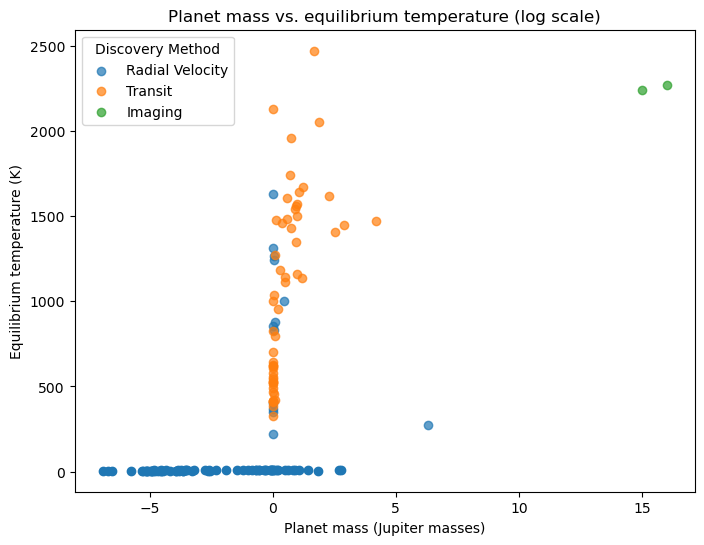

In [37]:
plt.figure(figsize=(8, 6))

discovery_methods = exo_filtered['discoverymethod'].unique()
colors = plt.cm.tab10.colors  # Up to 10 distinct colors

plt.scatter(np.log(exo_filtered['pl_bmassj']), np.log(exo_filtered['pl_eqt']))
for i, method in enumerate(discovery_methods):
    subset = exo_filtered[exo_filtered['discoverymethod'] == method]
    plt.scatter(
        subset['pl_bmassj'],
        subset['pl_eqt'],
        label=method,
        color=colors[i % len(colors)],
        alpha=0.7
    )
plt.xlabel('Planet mass (Jupiter masses)')
plt.ylabel('Equilibrium temperature (K)')
plt.title('Planet mass vs. equilibrium temperature (log scale)')
plt.legend(title='Discovery Method', loc='upper left')

plt.show()

Planets found by imaging are more likely to be small.

In [47]:
exo_filtered[exo_filtered['pl_bmassj'] > 5]
# The coldest planet is eps Ind A b, with an equilibrium temperature of 275 K.

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
493,USco1556 b,USco1556 A,Imaging,M3.0 V,2240.0,15.00
494,USco1621 b,USco1621 A,Imaging,M2.5 V,2270.0,16.00
581,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,6.31


In [52]:
print(exo_data.iloc[581])

pl_name           eps Ind A b
hostname            eps Ind A
default_flag                1
sy_snum                     3
sy_pnum                     1
                     ...     
sy_gaiamagerr1       0.007374
sy_gaiamagerr2      -0.007374
rowupdate          2024-08-07
pl_pubdate            2024-09
releasedate        2024-08-07
Name: 581, Length: 92, dtype: object


The planet is called eps Ind A b, and it is at index 581. Its equilibrium temperature is 275 K, and its mass is 6.31 Jupiter masses. It is orbiting a K type star, which is smaller and cooler than our Sun.

Paper title: "A temperate super-Jupiter imaged with JWST in the mid-infrared"
New data from JWST indicates that previously claimed properties of this planet were not actually true. It is likely the largest planet in its system and is considered a giant planet.
The answer that I got matches the exoplanet from this article.
This planet is special because it is very, very large.
The temperature and mass match what is listed in the article.